Notebook for KPZ surface simulations. 


## To do:

- Rewrite the surface detection algorithm. It should work roughly as follows. If there is a boundary between 
- Know when to expect artifacts from finite size.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple
import matplotlib.pyplot as plt

import numpy as np
import numba
from scipy.ndimage import binary_erosion

**Power jump sampling**. To sample from a jump $r$ from jump distribution $J(r, \mu)$ where $r_0 < r < \infty$, where normalized distribution is
$$
J(r, \mu) = \mu r_0^\mu r^{-(\mu+1)}
$$
we use inverse transform sampling. That is, we draw $F \sim \mathrm{Unif}[0,1]$ and then into the inverse CDF to get a draw $r$ from $J(r, \mu)$:
$$
r = r_0 (1-F)^{-1/\mu}
$$

In [3]:
def sample_power_law_jump(mu: float, rng: np.random.Generator, min_jump: float = np.sqrt(2)) -> float:
    """
    Sample jump distance xi from:
        J(xi, mu) = mu * xi^(-(mu + 1)),  xi >= min_jump
    via inverse transform sampling.

    Returns jump distasnce r in interval [min_jump, infty]
    """
    if mu <= 0:
        raise ValueError("mu must be > 0 for a normalizable jump distribution.")
    u = rng.random()
    return min_jump * (1.0 - u) ** (-1.0 / mu)

def fit_loglog_slope(x: np.ndarray, y: np.ndarray) -> float:
    """Fit slope in log-log space for positive x, y."""
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y) # get valid points that are positive and finite
    if np.count_nonzero(mask) < 2: # can only fit a line if there are more than 2 valid points
        return np.nan
    lx = np.log(x[mask])
    ly = np.log(y[mask])
    slope, _ = np.polyfit(lx, ly, deg=1) 
    return float(slope)

class StochasticGrowthStripGeometry:
    """Stochastic growth on L by L SQUARE lattice with 2 populations.
    Population A_1 -> 1
    Population A_2 -> 2
    Unoccupied -> 0
    
    Periodic boundary conditions in x (cylinder geometry)."""

    def __init__(self, L: int, mu: float, seed: int = 42):
        if L < 2:
            raise ValueError("L must be at least 2")
        self.L = int(L) 
        self.mu = float(mu) # jump kernel dist.
        self.rng = np.random.default_rng(seed) # random number generator for sims
        self.grid = np.zeros((self.L, self.L), dtype=np.int8)

        # initialize source strip
        self._initialize_strip()
        self.occupied_sites = [] # stores coordinates of all occupied sites
        ys, xs = np.where(self.grid > 0)
        for y, x in zip(ys, xs):
            self.occupied_sites.append((int(y), int(x)))
        
        self.time = 0 # This is used to index the histories
        self.attempts = 0 # This records the TRUE time which is increased every iteration
        self.accepted = 0
        self.history_t: List[int] = []
        self.history_max_height: List[int] = [] # max height history
        self.history_median_height: List[int] = [] # median height history (insensitive to large jumps)
        # self.history_surface: List[np.ndarray] = [] # saving this is probably overkill
        self.history_surface_width: List[np.ndarray] = []
        self.history_fill_fraction: List[float] = []
    
    def _initialize_strip(self) -> None: 
        half = self.L // 2 
        self.grid[0, :half] = 1 
        self.grid[0, half:] = 2 
    
    def step(self) -> bool: 
        """Run a growth step. Returns true if a new site is established. False otherwise."""
        self.attempts += 1
        idx = self.rng.integers(0, len(self.occupied_sites)) # randomly sample source site 
        sy, sx = self.occupied_sites[int(idx)] 
        pop_id = int(self.grid[sy, sx]) 

        # get jump coordinate
        jump = sample_power_law_jump(self.mu, self.rng, min_jump=1.0)
        theta = 2.0 * np.pi * self.rng.random()
        tx = int(round(sx + jump * np.cos(theta)))
        ty = int(round(sy + jump * np.sin(theta)))
        self.time += 1

        tx = tx % self.L  # periodic boundary in x (cylinder geometry)
        if ty < 0 or ty >= self.L: # out of bounds check in y
            return False
        if self.grid[ty, tx] != 0: # checks if square is already occupied
            return False

        # fills site with sampled population
        self.grid[ty, tx] = pop_id
        self.occupied_sites.append((ty, tx))
        self.accepted += 1
        return True
    
    def fill_fraction(self) -> float:
        return float(np.count_nonzero(self.grid) / (self.L * self.L))
    
    def max_interface_height(self) -> np.ndarray:
        """Get the max surface height at the current time step in the iteration."""
        h = np.zeros(self.L, dtype=np.float64)
        for x in range(self.L):
            ys = np.where(self.grid[:, x] > 0)[0]
            h[x] = ys.max() if ys.size else 0.0 # checks if a column is empty, if not sets h = to the highest y value
        return np.max(h)
    
    def median_interface_height(self) -> np.ndarray:
        """Get the median surface height at the current time step in the iteration."""
        h = np.zeros(self.L, dtype=np.float64)
        for x in range(self.L):
            ys = np.where(self.grid[:, x] > 0)[0]
            h[x] = ys.max() if ys.size else 0.0 # checks if a column is empty, if not sets h = to the highest y value
        return np.median(h)

    def extract_surface(self) -> np.ndarray:
        """Extract surface sites from the current grid configuration.

        Steps:
          1. Segment occupied sites into a binary image.
          2. Erode the binary image (default cross structuring element).
          3. XOR the original and eroded images to isolate surface sites.

        The returned array has dtype uint8: 1 = surface site, 0 = interior or empty.
        """
        binary = (self.grid > 0)
        eroded = binary_erosion(binary)
        surface = (binary ^ eroded).astype(np.uint8)
        # self.history_surface.append(surface) # commented out because this takes up too much memory
        return surface

    def extract_surface_width(self, surface: np.ndarray, l_min: int, l_max: int) -> np.ndarray:
        """Compute surface width w(l, t) for l_min <= l <= l_max.
        For each window width l, L windows are slid across the columns with
        periodic (wrap-around) boundary conditions matching the cylinder geometry.
        Within each window, every surface site contributes a point (local_x, y)
        to a linear fit y = a * local_x + b. The MSE of that fit is the window's
        contribution, and w(l) is the mean MSE over all L windows.
        Args:
            surface: 2D uint8 array of shape (L, L) from extract_surface,
                     where 1 marks a surface site.
            l_min:   Smallest window width to evaluate.
            l_max:   Largest window width to evaluate.
        Returns:
            Array of shape (l_max - l_min + 1,) containing w(l) for each l.
        """
        L = self.L
        # Per-column sufficient statistics computed in a single pass via bincount.
        # surface has shape (L_y, L_x); rows = y, cols = x.
        ys_idx, xs_idx = np.where(surface > 0)
        ys_f = ys_idx.astype(np.float64)
        n_col      = np.bincount(xs_idx, minlength=L).astype(np.float64)
        sum_y_col  = np.bincount(xs_idx, weights=ys_f,        minlength=L)
        sum_y2_col = np.bincount(xs_idx, weights=ys_f ** 2,   minlength=L)
        # Tile once to handle wrap-around; length 2L covers every window.
        n_ext   = np.tile(n_col,    2)
        sy_ext  = np.tile(sum_y_col,  2)
        sy2_ext = np.tile(sum_y2_col, 2)
        ls = np.arange(l_min, l_max + 1)
        widths = np.zeros(len(ls))
        for i, l in enumerate(ls):
            k = np.arange(l, dtype=np.float64)  # local x-positions, shape (l,)
            # Zero-copy sliding window views over tiled arrays; each row = one window.
            # sliding_window_view(arr, l)[:L] gives shape (L, l).
            n_w   = np.lib.stride_tricks.sliding_window_view(n_ext,   l)[:L]
            sy_w  = np.lib.stride_tricks.sliding_window_view(sy_ext,  l)[:L]
            sy2_w = np.lib.stride_tricks.sliding_window_view(sy2_ext, l)[:L]
            # Per-window aggregates via matrix-vector products, all shape (L,).
            n      = n_w.sum(axis=1)
            sum_x  = n_w  @ k
            sum_x2 = n_w  @ (k ** 2)
            sum_y  = sy_w.sum(axis=1)
            sum_xy = sy_w @ k
            sum_y2 = sy2_w.sum(axis=1)
            # OLS closed form: MSE = (SS_yy - SS_xy^2 / SS_xx) / n
            # Only compute for windows with at least 2 points.
            valid = n >= 2
            nv = n[valid]
            SS_xx = sum_x2[valid] - sum_x[valid] ** 2 / nv
            SS_xy = sum_xy[valid] - sum_x[valid] * sum_y[valid] / nv
            SS_yy = sum_y2[valid] - sum_y[valid] ** 2 / nv
            # Degenerate case: SS_xx == 0 means all points share the same column
            # (undefined slope), so fall back to variance of y about its mean.
            mse = np.sqrt(np.where(SS_xx > 0,
                           (SS_yy - SS_xy ** 2 / SS_xx) / nv,
                           SS_yy / nv))
            widths[i] = mse.mean() if mse.size > 0 else np.nan
        return widths

    def save(self, path: str) -> None:
        """Pickle the entire simulation state to a file.

        Saves everything: grid, histories, RNG state, and all parameters,
        so the simulation can be resumed exactly from this point.

        Usage:
            sim.save("my_sim.pkl")
        """
        import pickle
        with open(path, "wb") as f:
            pickle.dump(self, f)
        print(f"Simulation saved to {path}  (t={self.time}, accepted={self.accepted})")

    @classmethod
    def load(cls, path: str) -> "StochasticGrowthStripGeometry":
        """Load a simulation state from a pickle file and return it.

        Usage:
            sim = StochasticGrowthStripGeometry.load("my_sim.pkl")
            sim.run(...)   # continues from where it left off
        """
        import pickle
        with open(path, "rb") as f:
            obj = pickle.load(f)
        print(f"Simulation loaded from {path}  (t={obj.time}, accepted={obj.accepted})")
        return obj

    def save_snapshot(self, out_dir: Path, t: int, save_png: bool = False) -> None:
        """Saves a snapshot of the simulation"""
        max_height = self.max_interface_height()
        y_bound = int(3 * max_height)
        out_dir.mkdir(parents=True, exist_ok=True)
        npy_path = out_dir / f"snapshot_t{t:08d}.npy"
        np.save(npy_path, self.grid[:, :])
        if save_png:
            try:
                import matplotlib.pyplot as plt  # local import; optional dependency
            except Exception:
                return
            fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
            cmap = plt.matplotlib.colors.ListedColormap(["white", "#1f77b4", "#d62728"])
            ax.imshow(self.grid[:y_bound, :], origin="lower", cmap=cmap, vmin=0, vmax=2, interpolation="nearest")
            ax.set_title(f"L={self.L}, mu={self.mu}, t={t}")
            ax.set_xlabel("x")
            ax.set_ylabel("y")
            fig.tight_layout()
            fig.savefig(out_dir / f"snapshot_t{t:08d}.png")
            plt.close(fig)

    def run(self, n_steps: int, record_interval: int = 10,
                l_min: int = 20, l_max: Optional[int] = None,
                snapshot_steps: Optional[Iterable[int]] = None,
                snapshot_dir: Optional[str] = None,
                save_snapshots: bool = False):
        """Runs the simulation for n_steps and returns diagnostics.

        Args:
            n_steps:         Number of growth steps to simulate.
            record_interval: Record surface and width every this many time units.
            l_min:           Smallest window width for surface width calculation (default 20).
            l_max:           Largest window width for surface width calculation
                             (default L // 2).
            snapshot_steps:  Set of time values at which to save grid snapshots.
            snapshot_dir:    Directory to write snapshots into.
            save_snapshots:  Whether to also save PNG images of snapshots.
        """
        _l_max = l_max if l_max is not None else self.L // 2
        snapshot_set = set(snapshot_steps or [])
        out_dir = Path(snapshot_dir) if snapshot_dir else None

        for i in range(n_steps):
            print(f"Current progress: {i} of {n_steps}", end="\r")
            self.step()
            if self.time % record_interval == 0:
                self.history_t.append(self.time)
                self.history_max_height.append(self.max_interface_height())
                self.history_median_height.append(self.median_interface_height())
                self.history_fill_fraction.append(self.fill_fraction())
                surface = self.extract_surface()
                self.history_surface_width.append(
                    self.extract_surface_width(surface, l_min=l_min, l_max=_l_max)
                )
            if self.time in snapshot_set and out_dir is not None:
                self.save_snapshot(out_dir, self.time, save_png=save_snapshots)

        return {
            "t": np.asarray(self.history_t, dtype=np.float64),
            "max_height_history": np.asarray(self.history_max_height, dtype=np.float64),
            "median_height_history": np.asarray(self.history_median_height),
            # "surface_history": self.history_surface,
            "surface_width_history": np.asarray(self.history_surface_width, dtype=np.float64),
            "fill_fraction": np.asarray(self.history_fill_fraction, dtype=np.float64),
            "accepted": self.accepted
        }


def estimate_beta(t: np.ndarray, w: np.ndarray, early_fraction: float = 0.3) -> float:
    """Estimate growth exponent beta from early-time w ~ t^beta."""
    if not (0.0 < early_fraction <= 1.0):
        raise ValueError("early_fraction must be in (0, 1].")
    n = len(t)
    m = max(2, int(np.ceil(n * early_fraction)))
    return fit_loglog_slope(t[:m], w[:m])

def estimate_saturation_time(t: np.ndarray, w: np.ndarray, frac_of_plateau: float = 0.95) -> float:
    """
    Estimate saturation time t* as first time w(t) reaches given fraction of
    late-time average plateau. Note that this assumes that plateau was reached
    """
    if len(t) == 0:
        return np.nan
    tail_n = len(w) // 8 # times for tail of plateau
    plateau = float(np.mean(w[-tail_n:]))
    target = frac_of_plateau * plateau
    idx = np.where(w >= target)[0]
    if idx.size == 0:
        return np.nan
    return float(t[int(idx[0])])

def get_width_function(t: np.ndarray, h: np.ndarray, Ls: Iterable[int]) -> np.ndarray:
    """
    Takes inputs of time and the surface heights h(t, x). Outputs the surface width
    w(L, t) evaluated at chosen L values.
    """
    if max(Ls) > len(h):
        raise ValueError("Lengths (Ls) must be less than the total lattice dimension")
    w = [] # Container holding w(L, t) for each L
    for L in Ls:
        # Use a sliding window for each L and w(L, t) is the average 
        max_ind = len(h) - L + 1
        w_temp = []
        for i in range(max_ind):
            h_subsection = h[..., i:i+L]
            w_temp.append(np.std(h_subsection, axis=1))
        w.append(np.mean(w_temp, axis=1))
    return w

In [4]:
# run simulations 
sim = StochasticGrowthStripGeometry(L=1000, mu=5.0, seed=1920)
obs = sim.run(
    n_steps=1_000_000,
    record_interval=10_000,
    snapshot_steps=[i for i in range(0, 1_000_000 + 1, 50_000)],
    snapshot_dir="snapshots_L1000_mu3_pre_numba",
    save_snapshots=True,
)

In [ ]:
# save simulation after running
sim.save("sim_L500_mu3_t1M.pkl") 
# wow this is 2.5 GB

Simulation saved to sim_L500_mu3_t1M.pkl  (t=1000000, accepted=39140)


In [54]:
obs.keys()

dict_keys(['t', 'max_height_history', 'surface_width_history', 'fill_fraction', 'accepted'])

In [ ]:
obs['accepted']

39140

Median interface power: 0.5470425571904777
Max height interface power: 0.3955157228423781


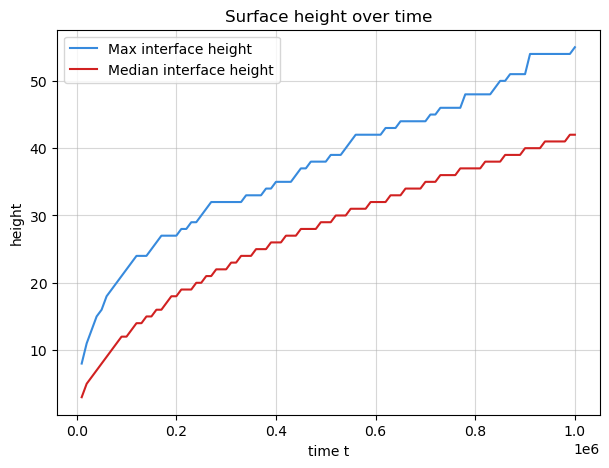

In [5]:
# plot surface heights over time
t = obs['t']
max_height = obs['max_height_history']
median_height = obs['median_height_history']
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(t, max_height, color='#378ADD', lw=1.5, label="Max interface height")
ax.plot(t, median_height, color="#d12121", lw=1.5, label="Median interface height")
ax.set_xlabel("time t")
ax.set_ylabel("height")
ax.set_title("Surface height over time")
ax.legend()
ax.grid(alpha=0.5)
print(f"Median interface power: {fit_loglog_slope(t, median_height)}")
print(f"Max height interface power: {fit_loglog_slope(t, max_height)}")

Mean log-log slope: 0.5201829916386904


"Comments:\nI don't think that these show signs of saturation. Why are these all so similar?\nMaybe the sliding window average is smoothing it out?\n"

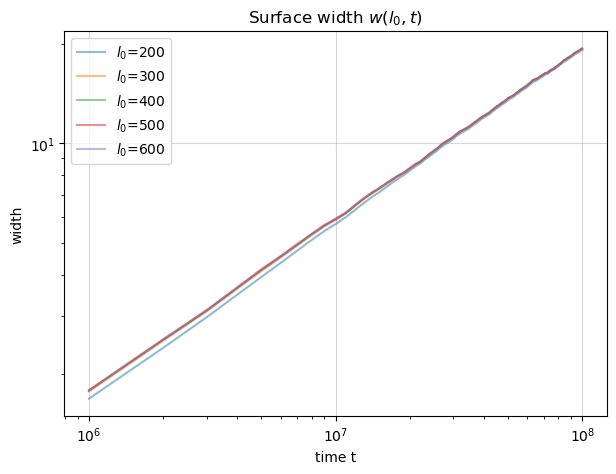

In [6]:
# plot w(l_0, t) as a function of time
log_log_slopes = []
t_dim, l_dim = np.shape(obs['surface_width_history'])
l_min = 200 # this is from simulation code
l_0s = [i for i in range(0, l_dim, 100)]
t = obs['t']*100
fig, ax = plt.subplots(figsize=(7, 5))
for l_0 in l_0s:
    w_l_0 = obs['surface_width_history'][:, l_0]
    log_log_slopes.append(fit_loglog_slope(t, w_l_0))
    ax.plot(t, w_l_0, lw=1.5, label=f"$l_0$={l_0+l_min}", alpha=0.5)
ax.set_xlabel("time t")
ax.set_ylabel("width")
ax.set_title("Surface width $w(l_0, t)$")
ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(alpha=0.5)
print(f"Mean log-log slope: {np.mean(log_log_slopes)}")

"""Comments:
I don't think that these show signs of saturation. Why are these all so similar?
Maybe the sliding window average is smoothing it out?
"""

---